<a href="https://colab.research.google.com/github/berrinaydogmus/softito-yapay-zeka/blob/main/istatistik1_18_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
#Veri yükleme
df = pd.read_csv("data.csv")

hizmet_puanlari = [
    "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Cleanliness"
]
sayisal_sutunlar = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"] + hizmet_puanlari
kategorik_sutunlar = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]

print(f"Veri seti: {df.shape[0]} satır, {df.shape[1]} sütun")
df.head()

Veri seti: 129880 satır, 22 sütun


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,False
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,False
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,True
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,False
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,True


In [ ]:
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_değer": df.isnull().sum(),
    "eksik_değer_yüzdesi": (df.isnull().mean()*100).round(2)
})
ozet

,dtype,n_unique,eksik_değer,eksik_değer_yüzdesi
Gender,object,2,0,0.0
Customer Type,object,2,0,0.0
Age,int64,75,0,0.0
Type of Travel,object,2,0,0.0
Class,object,3,0,0.0
Flight Distance,int64,3821,0,0.0
Inflight wifi service,int64,6,0,0.0
Departure/Arrival time convenient,int64,6,0,0.0
Ease of Online booking,int64,6,0,0.0
Gate location,int64,6,0,0.0


In [ ]:
#Özellik Kontrolü
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_değer": df.isnull().sum(),
    "eksik_değer_yüzdesi": (df.isnull().mean()*100).round(2)
})
ozet

,dtype,n_unique,eksik_değer,eksik_değer_yüzdesi
Gender,object,2,0,0.0
Customer Type,object,2,0,0.0
Age,int64,75,0,0.0
Type of Travel,object,2,0,0.0
Class,object,3,0,0.0
Flight Distance,int64,3821,0,0.0
Inflight wifi service,int64,6,0,0.0
Departure/Arrival time convenient,int64,6,0,0.0
Ease of Online booking,int64,6,0,0.0
Gate location,int64,6,0,0.0


In [ ]:
print("tekrar eden satır:", df.duplicated().sum())

# Arrival Delay in Minutes'ta eksik değerler var, bunlari 0 ile dolduralim
# cunku eksik olmasinin nedeni muhtemelen ucusun hic gecikmemesi
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(0)

for col in kategorik_sutunlar:
    print(f"\n{col}:")
    print(df[col].value_counts())

tekrar eden satır: 0

Gender:
Gender
Female    65899
Male      63981
Name: count, dtype: int64

Customer Type:
Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64

Type of Travel:
Type of Travel
Business travel    89693
Personal Travel    40187
Name: count, dtype: int64

Class:
Class
Business    62160
Eco         58309
Eco Plus     9411
Name: count, dtype: int64

satisfaction:
satisfaction
False    73452
True     56428
Name: count, dtype: int64


In [ ]:
df["hizmet_ortalama"] = df[hizmet_puanlari].mean(axis=1)

surekli_sutunlar = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes", "hizmet_ortalama"]

df[surekli_sutunlar].describe().round(2)

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,hizmet_ortalama
count,129880.00,129880.00,129880.00,129880.00,129880.00
mean,39.43,1190.32,14.71,15.05,3.21
std,15.12,997.45,38.07,38.42,0.67
min,7.00,31.00,0.00,0.00,1.00
25%,27.00,414.00,0.00,0.00,2.77
50%,40.00,844.00,0.00,0.00,3.23
75%,51.00,1744.00,12.00,13.00,3.69
max,85.00,4983.00,1592.00,1584.00,5.00


In [ ]:
#Betimsel İstatistik
def ortalama_guven_aralığı(seri, guven=0.95):
    veri = seri.dropna()
    n = len(veri)
    ortalama = veri.mean()
    sem = stats.sem(veri)
    t_kritik = stats.t.ppf((1+guven)/2, df=n-1)
    hata_payi = t_kritik * sem
    return ortalama, ortalama - hata_payi, ortalama + hata_payi

print(f"{'değişken':30s},{'Ortalama':>12s},{'%95 Alt':>12s},{'%95 Üst':>12s}")
for degisken in surekli_sutunlar:
    ortalama, alt, ust = ortalama_guven_aralığı(df[degisken])
    print(f"{degisken:30s},{ortalama:>12.2f},{alt:>12.2f},{ust:>12.2f}")

değişken                      ,    Ortalama,     %95 Alt,     %95 Üst
Age                           ,       39.43,       39.35,       39.51
Flight Distance               ,     1190.32,     1184.89,     1195.74
Departure Delay in Minutes    ,       14.71,       14.51,       14.92
Arrival Delay in Minutes      ,       15.05,       14.84,       15.25
hizmet_ortalama               ,        3.21,        3.21,        3.21


In [ ]:
betimsel = df[surekli_sutunlar].describe().T
betimsel["skew"] = df[surekli_sutunlar].skew()
betimsel["kurtosis"] = df[surekli_sutunlar].kurtosis()
betimsel.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,129880.0,39.43,15.12,7.0,27.00,40.00,51.00,85.0,-0.00,-0.72
Flight Distance,129880.0,1190.32,997.45,31.0,414.00,844.00,1744.00,4983.0,1.11,0.27
Departure Delay in Minutes,129880.0,14.71,38.07,0.0,0.00,0.00,12.00,1592.0,6.82,100.64
Arrival Delay in Minutes,129880.0,15.05,38.42,0.0,0.00,0.00,13.00,1584.0,6.68,95.36
hizmet_ortalama,129880.0,3.21,0.67,1.0,2.77,3.23,3.69,5.0,-0.06,-0.47


In [ ]:
#Normallik Testleri
print(f"{'Değişken':25s} {'Shapiro-Wilk p':>16s} {'DAgostino p':>16s}  Yorum")
for col in surekli_sutunlar:
    veri = df[col].dropna()
    ornek = veri.sample(min(len(veri), 5000), random_state=0)
    sw_stat, sw_p = stats.shapiro(ornek)
    da_stat, da_p = stats.normaltest(veri)
    yorum = "Normal dağılım varsayımı sağlanmaktadır." if sw_p > 0.05 else "Normal dağılım varsayımı sağlanmamaktadır."
    print(f"{col:25s} {sw_p:>16.4f} {da_p:>16.4f}  {yorum}")

Değişken                    Shapiro-Wilk p      DAgostino p  Yorum
Age                                 0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.
Flight Distance                     0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.
Departure Delay in Minutes           0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.
Arrival Delay in Minutes            0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.
hizmet_ortalama                     0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.


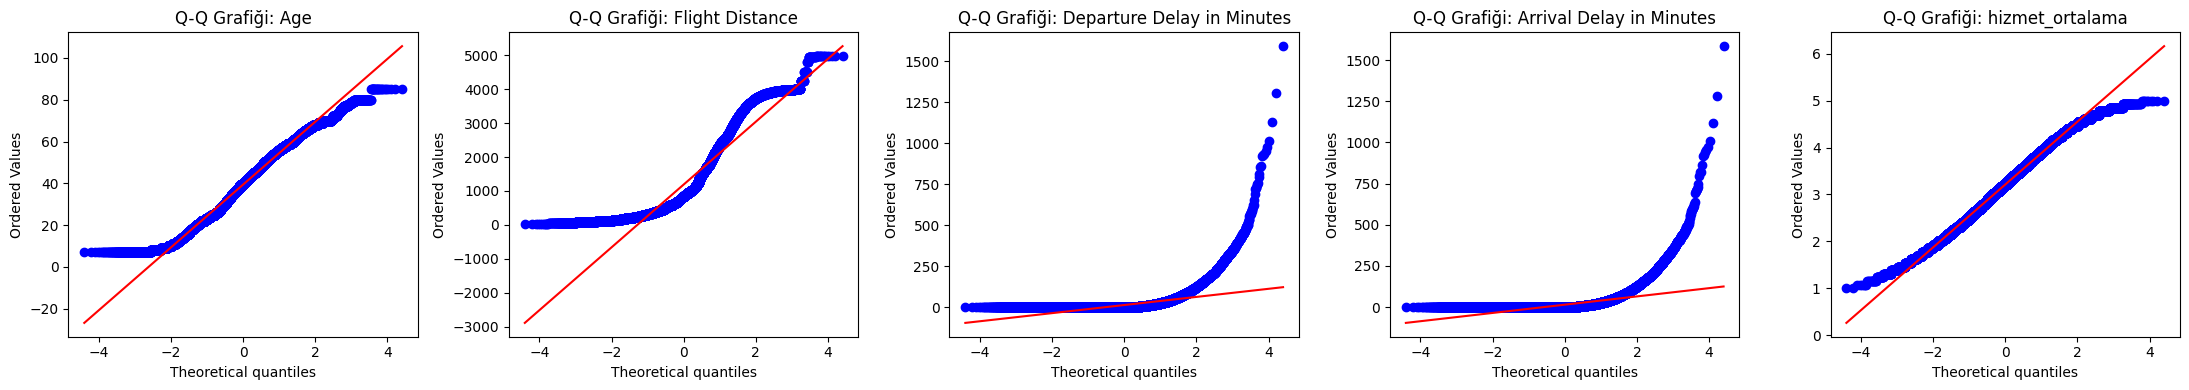

In [ ]:
fig, axes = plt.subplots(1, len(surekli_sutunlar), figsize=(22, 4))
for ax, col in zip(axes, surekli_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()

In [ ]:
#İki Grup Karşılaştırması
grup0 = df.loc[df["satisfaction"] == False, "hizmet_ortalama"].dropna()
grup1 = df.loc[df["satisfaction"] == True, "hizmet_ortalama"].dropna()

levene_stat, levene_p = stats.levene(grup0, grup1)
print("Varsayımlar homojendir." if levene_p > 0.05 else "Varsayımlar homojen değildir.")

__, p0 = stats.shapiro(grup0.sample(min(len(grup0), 5000), random_state=0))
__, p1 = stats.shapiro(grup1.sample(min(len(grup1), 5000), random_state=0))
print(f"grup normallik p değerleri: satisfaction=False -> {p0:.4f}, satisfaction=True -> {p1:.4f}")

u_stat, mw_p = stats.mannwhitneyu(grup0, grup1)
t_stat, t_p = stats.ttest_ind(grup0, grup1, equal_var=(levene_p > 0.05))
print(f"\nBağımsız örneklem t-testi: t={t_stat:.3f}, p={t_p:.4g}")
print(f"Mann-Whitney U testi:      U={u_stat:.3f}, p={mw_p:.4g}")
print(f"\nOrtalama hizmet puanı -> memnun değil: {grup0.mean():.3f}, memnun: {grup1.mean():.3f}")

Varsayımlar homojen değildir.
grup normallik p değerleri: satisfaction=False -> 0.0000, satisfaction=True -> 0.0000

Bağımsız örneklem t-testi: t=-202.366, p=0
Mann-Whitney U testi:      U=867407823.000, p=0

Ortalama hizmet puanı -> memnun değil: 2.920, memnun: 3.588


In [ ]:
#Çoklu Grup Karşılaştırması
gruplar = [g["hizmet_ortalama"].dropna().values for _, g in df.groupby("Class")]

f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p = stats.kruskal(*gruplar)

print(f"tek yönlü anova: f={f_stat:.3f}, p={anova_p:.4g}")
print(f"kruskal-wallis: h={h_stat:.3f}, p={kw_p:.4g}")

tek yönlü anova: f=5174.969, p=0
kruskal-wallis: h=9555.444, p=0


In [ ]:
genel_ortalama = df["hizmet_ortalama"].mean()
ss_between = sum(len(g)*(g.mean()-genel_ortalama)**2 for g in gruplar)
ss_total = sum((df["hizmet_ortalama"].dropna()-genel_ortalama)**2)
eta_kare = ss_between/ss_total
print(f"Eta Kare: {eta_kare:.4f} (0.01 küçük, 0.06 orta, 0.14 büyük etki)")

Eta Kare: 0.0738 (0.01 küçük, 0.06 orta, 0.14 büyük etki)


In [ ]:
tukey = pairwise_tukeyhsd(
    endog=df["hizmet_ortalama"].dropna(),
    groups=df.loc[df["hizmet_ortalama"].notna(), "Class"],
    alpha=0.05
)
print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj  lower   upper  reject
-------------------------------------------------------
Business      Eco  -0.3655   0.0 -0.3742 -0.3567   True
Business Eco Plus  -0.3658   0.0 -0.3825  -0.349   True
     Eco Eco Plus  -0.0003 0.999 -0.0171  0.0165  False
-------------------------------------------------------


In [ ]:
#Kategorik Değişkenler Arasındaki İlişki
def cramers_v(x, y):
    tablo = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tablo)[0]
    n = tablo.sum().sum()
    k = min(tablo.shape) - 1
    return np.sqrt(chi2/(n*k))

for col in ["Class", "Customer Type", "Type of Travel", "Gender"]:
    capraz = pd.crosstab(df[col], df["satisfaction"])
    chi2, p, dof, beklenen = stats.chi2_contingency(capraz)
    v = cramers_v(df[col], df["satisfaction"])
    print(f"{col:16s} vs satisfaction -> chi2={chi2:9.2f}, p={p:.4g}, Cramer's V={v:.4f}")

Class            vs satisfaction -> chi2= 32906.17, p=0, Cramer's V=0.5033
Customer Type    vs satisfaction -> chi2=  4493.19, p=0, Cramer's V=0.1860
Type of Travel   vs satisfaction -> chi2= 26282.52, p=0, Cramer's V=0.4498
Gender           vs satisfaction -> chi2=    16.35, p=5.26e-05, Cramer's V=0.0112


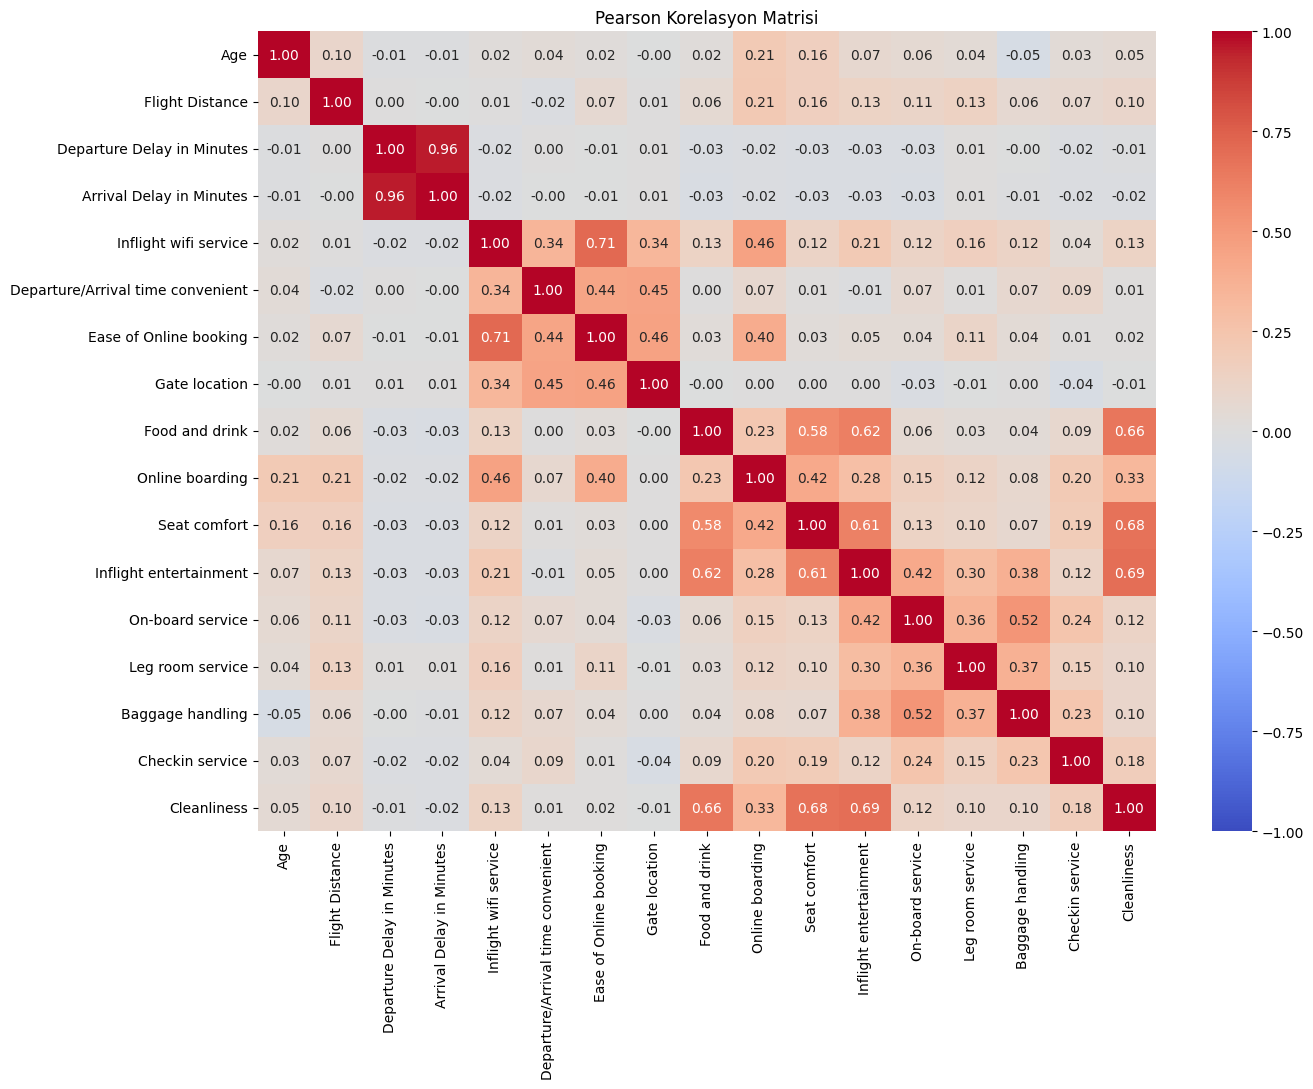

In [ ]:
#Korelasyon Analizi
korelasyon_sutunlari = surekli_sutunlar[:-1] + hizmet_puanlari
pearson_r = df[korelasyon_sutunlari].corr(method="pearson")

plt.figure(figsize=(14, 11))
sns.heatmap(pearson_r, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson Korelasyon Matrisi")
plt.tight_layout()
plt.show()

In [ ]:
X_vif = df[hizmet_puanlari].dropna()
X_vif = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": X_vif.columns[1:],
    "VIF": [VIF(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})
print(vif_tablosu.sort_values("VIF", ascending=False).to_string(index=False))

                         Değişken      VIF
           Inflight entertainment 3.548741
                      Cleanliness 2.808033
           Ease of Online booking 2.627949
                     Seat comfort 2.337644
            Inflight wifi service 2.334170
                   Food and drink 2.144257
                  Online boarding 1.765511
                 On-board service 1.668475
                 Baggage handling 1.607468
                    Gate location 1.484981
Departure/Arrival time convenient 1.428209
                 Leg room service 1.278577
                  Checkin service 1.196810


In [ ]:
model_verisi = df[["satisfaction", "Online boarding", "Inflight wifi service", "Flight Distance", "Age"]].dropna().copy()
model_verisi["satisfaction"] = model_verisi["satisfaction"].astype(int)

model = smf.logit(
    formula="satisfaction ~ Q('Online boarding') + Q('Inflight wifi service') + Q('Flight Distance') + Age",
    data=model_verisi
)
sonuc = model.fit()
print(sonuc.summary())

print("\nOdds Ratio'lar (katsayının e üssü):")
print(np.exp(sonuc.params))

Optimization terminated successfully.
         Current function value: 0.509117
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           satisfaction   No. Observations:               129880
Model:                          Logit   Df Residuals:                   129875
Method:                           MLE   Df Model:                            4
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                  0.2563
Time:                        13:21:10   Log-Likelihood:                -66124.
converged:                       True   LL-Null:                       -88907.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -4.7752      0.033   -146.534      0.000      

Bileşen başına açıklanan varyans oranı:
[0.2773 0.1822 0.1368 0.0807 0.073  0.0518 0.041  0.0392 0.0355 0.0253
 0.0226 0.0196 0.0151]

Kümülatif açıklanan varyans:
[0.2773 0.4595 0.5963 0.677  0.75   0.8018 0.8428 0.8819 0.9174 0.9427
 0.9653 0.9849 1.    ]


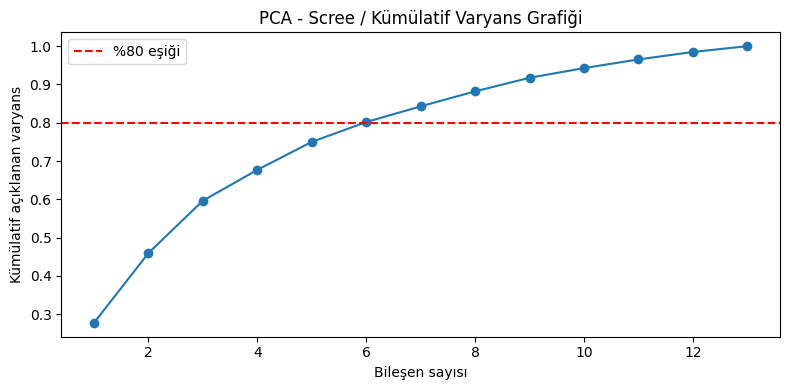

In [ ]:
pca_verisi = df[hizmet_puanlari].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_verisi)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
acıklanan_varyans = pca.explained_variance_ratio_

print("Bileşen başına açıklanan varyans oranı:")
print(acıklanan_varyans.round(4))
print("\nKümülatif açıklanan varyans:")
print(np.cumsum(acıklanan_varyans).round(4))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(acıklanan_varyans)+1), np.cumsum(acıklanan_varyans), marker="o")
plt.axhline(0.8, color="red", linestyle="--", label="%80 eşiği")
plt.xlabel("Bileşen sayısı")
plt.ylabel("Kümülatif açıklanan varyans")
plt.title("PCA - Scree / Kümülatif Varyans Grafiği")
plt.legend()
plt.tight_layout()
plt.show()